In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [4]:
df = pd.read_csv(r'C:\Users\ASUS\Downloads\rideshare_kaggle.csv')
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  str    
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  str    
 6   timezone                     693071 non-null  str    
 7   source                       693071 non-null  str    
 8   destination                  693071 non-null  str    
 9   cab_type                     693071 non-null  str    
 10  product_id                   693071 non-null  str    
 11  name                         693071 non-null  str    
 12  price                        637976 non-null  float64
 13  distance  

In [6]:
df.isnull().sum()

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [7]:
df = df.dropna()

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

id                             0
timestamp                      0
hour                           0
day                            0
month                          0
datetime                       0
timezone                       0
source                         0
destination                    0
cab_type                       0
product_id                     0
name                           0
price                          0
distance                       0
surge_multiplier               0
latitude                       0
longitude                      0
temperature                    0
apparentTemperature            0
short_summary                  0
long_summary                   0
precipIntensity                0
precipProbability              0
humidity                       0
windSpeed                      0
windGust                       0
windGustTime                   0
visibility                     0
temperatureHigh                0
temperatureHighTime            0
temperatur

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 637976 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  str    
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  str    
 6   timezone                     637976 non-null  str    
 7   source                       637976 non-null  str    
 8   destination                  637976 non-null  str    
 9   cab_type                     637976 non-null  str    
 10  product_id                   637976 non-null  str    
 11  name                         637976 non-null  str    
 12  price                        637976 non-null  float64
 13  distance       

In [25]:
# --- JALANKAN INI DALAM SATU SEL ---
import pandas as pd

# 1. Pilih kolom yang berkorelasi
selected_cols = ['distance', 'surge_multiplier', 'name', 'price']
df_model = df[selected_cols].dropna()

# 2. Definisikan X dan y (Gunakan X BESAR)
X = df_model.drop('price', axis=1)
y = df_model['price']

# 3. Sekarang lakukan get_dummies
X = pd.get_dummies(X, columns=['name'], drop_first=True)

# 4. Cek apakah berhasil
print("Variabel X berhasil didefinisikan!")
print(X.head())

Variabel X berhasil didefinisikan!
   distance  surge_multiplier  name_Black SUV  name_Lux  name_Lux Black  \
0      0.44               1.0           False     False           False   
1      0.44               1.0           False      True           False   
2      0.44               1.0           False     False           False   
3      0.44               1.0           False     False           False   
4      0.44               1.0           False     False           False   

   name_Lux Black XL  name_Lyft  name_Lyft XL  name_Shared  name_UberPool  \
0              False      False         False         True          False   
1              False      False         False        False          False   
2              False       True         False        False          False   
3               True      False         False        False          False   
4              False      False          True        False          False   

   name_UberX  name_UberXL  name_WAV  
0       Fals

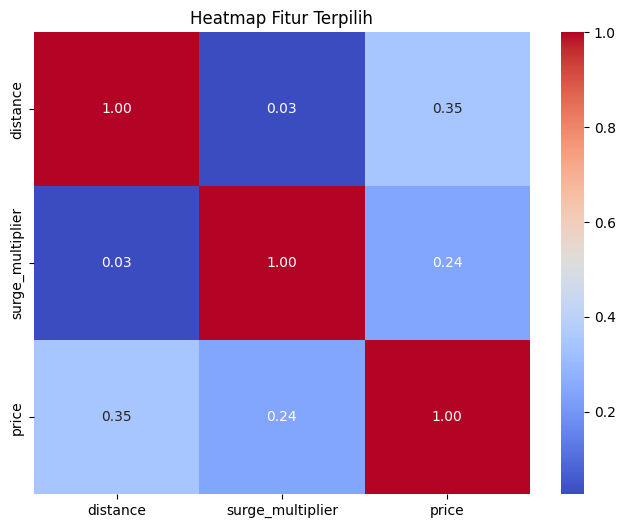

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tentukan fitur yang masuk dalam model (termasuk target 'price')
fitur_model = ['distance', 'surge_multiplier', 'price'] 

# 2. Buat heatmap hanya untuk fitur tersebut
plt.figure(figsize=(8, 6))
sns.heatmap(df[fitur_model].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Fitur Terpilih")
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# Inisialisasi model
model = LinearRegression()

# Pelatihan model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# 1. Melakukan prediksi
y_pred = model.predict(X_test)

# 2. Menghitung metrik evaluasi
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred) # Versi baru scikit-learn
r2 = r2_score(y_test, y_pred)

# 3. Menampilkan hasil
print("=========== HASIL EVALUASI MODEL ===========")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-Squared (R2 Score)          : {r2:.4f}")
print("============================================")

# Opsional: Jika ingin membandingkan dengan nilai rata-rata target
print(f"Rata-rata Harga (Price)       : {y_test.mean():.4f}")

=========== HASIL EVALUASI MODEL ===========
Mean Squared Error (MSE)      : 6.3296
Root Mean Squared Error (RMSE): 2.5159
R-Squared (R2 Score)          : 0.9274
Rata-rata Harga (Price)       : 16.5423
